# Часть 1

## Этап 1

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from sklearn.model_selection import train_test_split
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.viz import plot_uplift_curve
from causalml.inference.meta import BaseSClassifier
from sklearn.ensemble import RandomForestClassifier
from sklift.metrics import uplift_auc_score, qini_auc_score
from itertools import product

In [2]:
data = pd.read_csv("uplift_fp_data.csv")

In [15]:
data

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...
63995,10,1,105.54,1,0,0,0,2,0,0
63996,5,0,38.91,0,1,0,1,1,0,0
63997,6,0,29.99,1,0,0,1,1,0,0
63998,1,4,552.94,1,0,1,1,0,1,0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


в датасете нет пропусков

## Этап 2

### EDA


In [3]:
val_count = data.groupby("treatment")["target"].agg(["mean", "count"]).reset_index()

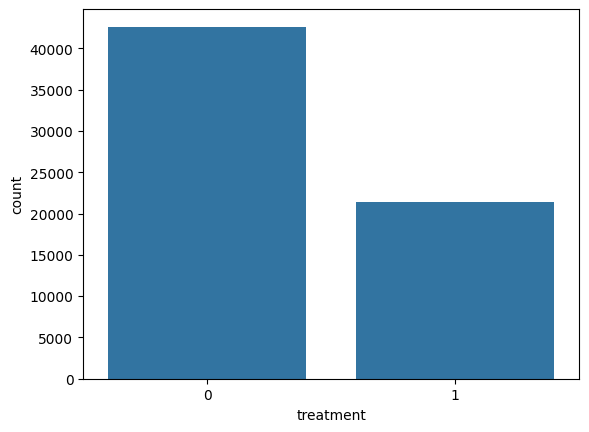

In [21]:
sns.barplot(x=val_count["treatment"], y=val_count["count"], data=val_count)
plt.show()

Сделайте вывод на основе EDA в данной ячейке

Получается число объектов в контрольной группе больше чем в тестовой, будем учитывать при обучений модели

# Этап 2

### Проверка на статистическую значимость

Обоснуйте выбор статистического теста в данной ячейке

In [3]:
treatment_1 = data[data["treatment"]== 1]
control = data[data["treatment"] == 0]

In [25]:
control.describe()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,42613.000000,42613.000000,42613.000000,42613.000000,42613.000000,42613.000000,42613.000000,42613.000000,42613.0,42613.000000
mean,5.761669,1.479924,241.859315,0.552085,0.549527,0.748363,0.501748,1.321029,0.0,0.144463
std,3.505422,1.547430,256.574723,0.497286,0.497547,0.698470,0.500003,0.679146,0.0,0.351563
min,1.000000,0.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,2.000000,0.000000,64.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000
50%,6.000000,1.000000,157.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.000000
75%,9.000000,2.000000,325.210000,1.000000,1.000000,1.000000,1.000000,2.000000,0.0,0.000000
max,12.000000,6.000000,3345.930000,1.000000,1.000000,2.000000,1.000000,2.000000,0.0,1.000000


In [26]:
treatment_1.describe()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,21387.000000,21387.000000,21387.000000,21387.000000,21387.000000,21387.000000,21387.000000,21387.000000,21387.0,21387.000000
mean,5.767850,1.486043,242.536633,0.548932,0.550101,0.748679,0.503250,1.316781,1.0,0.151400
std,3.511989,1.538717,255.332880,0.497612,0.497495,0.696887,0.500001,0.676481,0.0,0.358447
min,1.000000,0.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,2.000000,0.000000,65.040000,0.000000,0.000000,0.000000,0.000000,1.000000,1.0,0.000000
50%,6.000000,1.000000,160.090000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.000000
75%,9.000000,2.000000,326.820000,1.000000,1.000000,1.000000,1.000000,2.000000,1.0,0.000000
max,12.000000,6.000000,3040.200000,1.000000,1.000000,2.000000,1.000000,2.000000,1.0,1.000000


средние значения и стандартные отклонения у обеих групп почти одинаковы

In [5]:
conv_in_treatment_gr = treatment_1["target"].sum() / len(treatment_1)
conv_in_control_gr = control["target"].sum() / len(control)
conv_in_treatment_gr, conv_in_control_gr
print(f"Конверсия в тестовой группе: {conv_in_treatment_gr:3f}")
print(f"Конверсия в контрольной группе: {conv_in_control_gr:3f}")

Конверсия в тестовой группе: 0.151400
Конверсия в контрольной группе: 0.144463


In [6]:
uplift = conv_in_treatment_gr - conv_in_control_gr
print(f"uplift: {uplift:4f}")

uplift: 0.006937


In [7]:
stat, p_value = proportions_ztest([treatment_1["target"].sum(), control["target"].sum()], [len(treatment_1), len(control)])

In [8]:
stat, p_value

(2.339315972581879, 0.019319086659790173)

## Построение корреляций

In [15]:
plt.figure(figsize=(30, 24))
correlation_matrix = (data.drop(columns=["treatment"]).corr())

<Figure size 3000x2400 with 0 Axes>

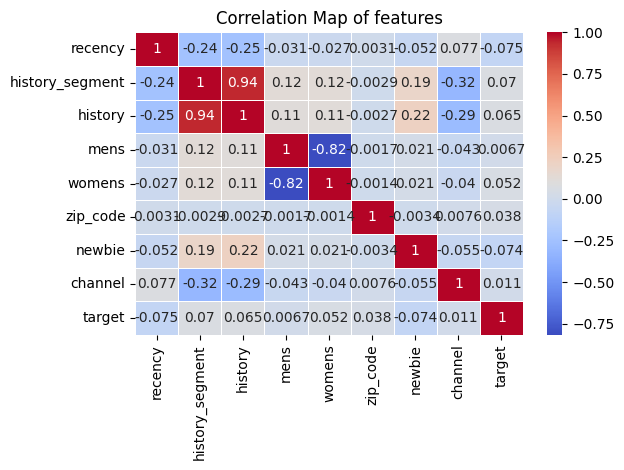

In [16]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Map of features")
plt.tight_layout()
plt.show()

Между признаками newbie, history и history_segment наблюдается слабая корреляция, однако с целевой переменной и другими признаками сильной корреляции не выявлено

В ходе EDA не было выявлено аномалий или явных закономерностей; однако объёмы тестовой и контрольной выборок не соответствуют друг другу

## Этап 3

Обоснуйте выбор конкретной uplift модели в данной ячейке

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [4]:
X = data.drop(["target"], axis=1)
y = data["target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=data[["target", "treatment"]], random_state=42)

In [17]:
treatment_mapping = {
    0: "control",
    1: "treatment"
}

In [18]:
X_train["treatment"] = X_train["treatment"].map(treatment_mapping)
X_test["treatment"] = X_test["treatment"].map(treatment_mapping)

### Обучение выбранного бейзлайна

In [48]:
uplift_model = UpliftRandomForestClassifier(control_name="control")

In [49]:
uplift_model.fit(X_train.drop(columns=['treatment']).values,
                 treatment=X_train["treatment"].values,
                 y=y_train.values)

In [50]:
uplift_scores = uplift_model.predict(X_test.drop(columns=["treatment"]), full_output=False)

In [51]:
top_percent = 0.05
top_5_percent = np.sort(uplift_scores)[::-1][:int(len(uplift_scores) * top_percent)]

### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [52]:
print(f"Количество клиентов в верхних 5%: {len(top_5_percent)}")
print(f"Минимальное значение uplift в верхних 5%: {np.min(top_5_percent):.2f}")
print(f"Максимальное значение uplift в верхних 5%: {np.max(top_5_percent):.2f}")
print(f"Среднее значение uplift: {np.mean(top_5_percent):.2f}")

Количество клиентов в верхних 5%: 960
Минимальное значение uplift в верхних 5%: -0.09
Максимальное значение uplift в верхних 5%: 0.12
Среднее значение uplift: 0.01


# Обучение 2 моделей 

### Обучение модели 1

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=data[["target", "treatment"]], random_state=42)

In [54]:
model = RandomForestClassifier(
    n_estimators=100,  
    max_depth=6,       
    random_state=42,  
    verbose=1         
)

In [57]:
model.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.9s finished


RandomForestClassifier(max_depth=6, random_state=42, verbose=1)

### Получение метрик по модели 1

In [25]:
X_test_treated = X_test.copy()
X_test_control = X_test.copy()

In [26]:
X_test_treated['treatment'] = 1  # С воздействием
X_test_control['treatment'] = 0  # Без воздействия

In [61]:
y_pred_treated = model.predict_proba(X_test_treated)[:,1]
y_pred_control = model.predict_proba(X_test_control)[:,1]

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


In [62]:
uplift = y_pred_treated - y_pred_control

In [63]:
X_test['predicted_uplift'] = uplift

In [64]:
print("Пользователи с наибольшим положительным uplift (наиболее отзывчивые на скидку):")
print(X_test.sort_values(by='predicted_uplift', ascending=False).head(5))

print("Пользователи с наименьшим uplift (скидка может быть неэффективна):")
print(X_test.sort_values(by='predicted_uplift', ascending=True).head(5)) 

Пользователи с наибольшим положительным uplift (наиболее отзывчивые на скидку):
       recency  history_segment  history  mens  womens  zip_code  newbie  \
55171        5                6  1310.55     0       1         2       1   
60248       11                6  1229.68     0       1         1       1   
5716        11                6  1108.21     0       1         0       1   
53434       11                5   902.05     0       1         0       1   
53020       12                4   646.80     0       1         1       1   

       channel  treatment  predicted_uplift  
55171        2          1          0.036417  
60248        0          1          0.029711  
5716         2          0          0.029667  
53434        1          1          0.028891  
53020        2          1          0.028516  
Пользователи с наименьшим uplift (скидка может быть неэффективна):
       recency  history_segment  history  mens  womens  zip_code  newbie  \
29306        1                2   225.35    

### Обучение модели 2

In [7]:
learner = RandomForestClassifier(
    n_estimators=100,  
    max_depth=6,      
    random_state=42,  
    verbose=1         
)

In [8]:
s_learner = BaseSClassifier(
    learner=learner, # Базовая модель (в данном случае случайный лес)
    control_name=0,  # Значение признака treatment для контрольной группы
)

In [9]:
s_learner.fit(X_train.values, treatment=X_train['treatment'], y=y_train.values)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.7s finished


In [ ]:
X_test = X_test.drop(columns=['predicted_uplift'])

In [11]:
uplift_vals = s_learner.predict(np.array(X_test.values.copy())).squeeze()

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished


### Получение метрик по модели 2

In [12]:
uplift_score = uplift_auc_score(y_test.values, uplift_vals, X_test['treatment'].values)
qini_score = qini_auc_score(y_test.values, uplift_vals, X_test['treatment'].values)

In [13]:
print(f"Uplift AUC: {uplift_score:.2f}")
print(f"Qini AUC: {qini_score:.2f}")

Uplift AUC: 0.03
Qini AUC: 0.06


Uplift score и Qini score составили 0.03 и 0.06 соответственно. При обучении модели UpliftRandomForestClassifier среднее значение uplift-метрики оказалось на уровне 0.01. В то же время модель, обученная с использованием алгоритма S-learner, продемонстрировала более высокие результаты. Классическая модель RandomForestClassifier показала значения 0.36 и 0.29, что также указывает на наличие положительного эффекта

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

In [ ]:
max_uplift = 0
top_percent = 0.3
best_params = {}

eval_functions = ['KL', 'ED', 'Chi']
max_depths = [6, 7, 8]
n_estimators = [50, 100]

In [19]:
results = []
for eval_f, m_depth, n_est in product(eval_functions, max_depths, n_estimators):
    uplift_model = UpliftRandomForestClassifier(
        control_name='control',
        evaluationFunction=eval_f,
        max_depth=m_depth,
        n_estimators=n_est,
        random_state=42
    )

    uplift_model.fit(
        X_train.drop(columns=['treatment']).values,
        treatment=X_train['treatment'].values,
        y=y_train.values
    )

    uplift_preds = uplift_model.predict(X_test.drop(columns=['treatment']), full_output=False)
    uplift_preds_df = (pd.DataFrame(uplift_preds, columns = ['uplift_score'])
                ['uplift_score']
                .sort_values(ascending=False)
    )

    mean_uplift = (uplift_preds_df
                [:int(len(uplift_preds_df) * top_percent)]
                .mean()
    )

    results.append({
        'eval_function': eval_f,
        'max_depth': m_depth,
        'n_estimators': n_est,
        'mean_uplift@10%': mean_uplift
    })

    if mean_uplift > max_uplift:
        max_uplift = mean_uplift
        best_params = {
            "eval_function": eval_f,
            "max_depth": m_depth,
            "n_estimators": n_est
        }

In [20]:
results_df = pd.DataFrame(results)

In [30]:
print("Best params:", best_params)
print("Best uplift@30%:", max_uplift)

Best params: {'eval_function': 'ED', 'max_depth': 8, 'n_estimators': 50}
Best uplift@30%: 0.07944186852685117


#### Генерация признаков (опционально)

### Подбор гиперпараметров

In [35]:
from optuna import create_study
import optuna
from sklift.metrics import uplift_at_k

def objective(trial: optuna.Trial):

    n_estimators = trial.suggest_int("n_estimators", 50, 100)
    max_depth = trial.suggest_int("max_depth", 2, 6)
    
    learner = RandomForestClassifier(
    n_estimators=n_estimators,  
    max_depth=max_depth,      
    random_state=42,  
    verbose=1         
)
    s_learner = BaseSClassifier(
    learner=learner, # Базовая модель (в данном случае случайный лес)
    control_name=0,  # Значение признака treatment для контрольной группы
)

    s_learner.fit(X_train.values, treatment=X_train['treatment'], y=y_train.values)
    uplift_preds = s_learner.predict(np.array(X_test.values.copy())).squeeze()

    uplift_at_30 = uplift_at_k(y_test, uplift_preds, X_test["treatment"], k=0.3, strategy='overall')
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)

# Выводим лучшие гиперпараметры
print("Best hyperparameters: ", study.best_params)
print("Best score: ", study.best_value)


[I 2026-04-07 11:41:15,192] A new study created in memory with name: no-name-b95f3497-8902-4b0a-9fbc-a6fdbc138524
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done  70 out of  70 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  70 out of  70 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  70 out of  70 | elapsed:    0.1s finished
[I 2026-04-07 11:41:16,206] Trial 0 finished with value: 0.045898361674043014 and parameters: {'n_estimators': 70, 'max_depth': 4}. Best is trial 0 with value: 0.045898361674043014.
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done  93 out of  93 | elapsed:    1.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  93 out of  93 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elaps

Best hyperparameters:  {'n_estimators': 77, 'max_depth': 3}
Best score:  0.05133827987364442


## Этап 2

### Визуализация результатов

In [36]:
from utils import custom_uplift_by_percentile
from sklift.metrics import uplift_by_percentile

In [37]:
learner = RandomForestClassifier(
    n_estimators=study.best_params["n_estimators"],  
    max_depth=study.best_params["max_depth"],      
    random_state=42,  
    verbose=1         
)
s_learner = BaseSClassifier(
    learner=learner, # Базовая модель (в данном случае случайный лес)
    control_name=0,  # Значение признака treatment для контрольной группы
)

s_learner.fit(X_train.values, treatment=X_train['treatment'], y=y_train.values)
uplift_preds = s_learner.predict(np.array(X_test.values.copy())).squeeze()

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done  77 out of  77 | elapsed:    0.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  77 out of  77 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  77 out of  77 | elapsed:    0.1s finished


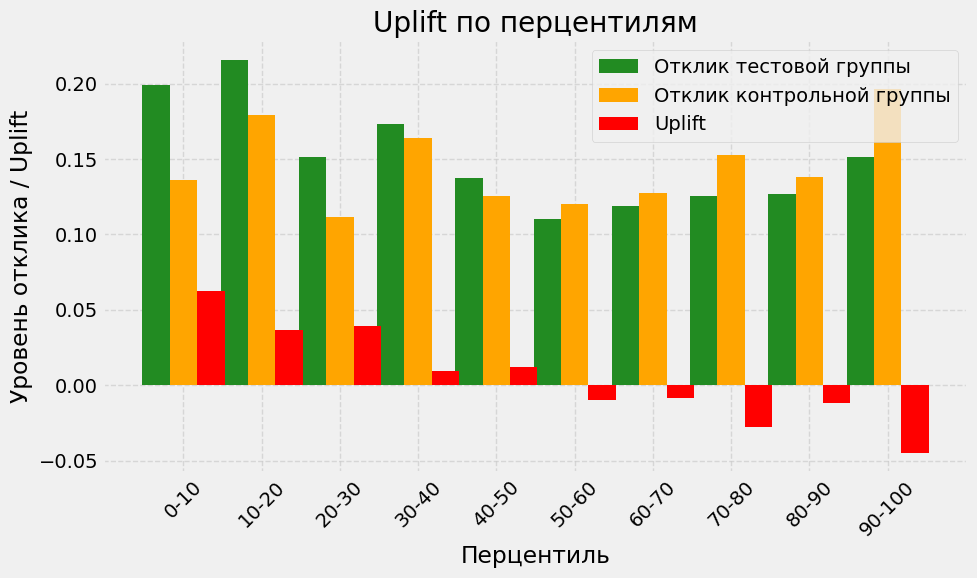

In [43]:
conversion = y_test
treatment = X_test["treatment"]
uplift = uplift_preds.copy()


fig = custom_uplift_by_percentile(
    conversion, 
    uplift, 
    treatment,  
    kind='bar',  
    bins=10, 
    title='Uplift по перцентилям' 
)

Как видно на графике, в начальной части перцентилей наблюдается положительный uplift

# Этап 3

In [45]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания 
            logger: Объект для логирования (по умолчанию None)
        """
        self.model = model
        self.feature_names = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
        self.logger = logger
        
        if self.logger:
            self.logger.info("Модель UpliftModel инициализирована с признаками: %s", feature_names)

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # реализуйте преобразование данных для модели,
        # если в финальной модели используются новые признаки
       

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None]*len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)

            return [None]*len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        

        # Дополните код для получения предсказаний аплифта

        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift


In [46]:
model = UpliftModelInference(model=s_learner,
                             feature_names=X.columns.to_list())

In [47]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [48]:
# проверка работы класса
model.predict(test_data)

array([-8.18457456e-04, -9.29520026e-05,  5.92473747e-04, ...,
        5.44814479e-04,  1.86279368e-03,  0.00000000e+00])